<a href="https://colab.research.google.com/github/SwayashmCS23157/MLkiRepository/blob/main/Swayash_prac5Extra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/ML/Gaming and Mental Health.csv"
df=pd.read_csv(path)
df.head(5)

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [ ]:
df = df.drop("record_id", axis=1)

In [ ]:
bool_cols = df.select_dtypes(include="bool").columns

for col in bool_cols:
    df[col] = df[col].astype(int)

In [ ]:
label_encoders = {}

for col in df.select_dtypes(include="object").columns:
    if col != "gaming_addiction_level":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

In [ ]:
target_encoder = LabelEncoder()
df["gaming_addiction_risk_level"] = target_encoder.fit_transform(
    df["gaming_addiction_risk_level"]
)

In [ ]:
target_encoder.classes_

array([0, 1, 2, 3])

In [ ]:
X = df.drop("gaming_addiction_risk_level", axis=1)
y = df["gaming_addiction_risk_level"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[2 0 2 0 3 0 1 1 3 1 2 1 1 2 3 3 1 1 2 1 0 3 0 1 3 1 3 1 1 1 3 1 1 2 3 1 2
 1 2 2 1 1 1 1 3 1 0 1 3 2 0 1 2 2 1 2 2 3 1 1 1 2 1 1 2 1 2 1 2 1 1 1 1 1
 2 1 0 1 2 1 1 3 1 3 0 3 1 0 3 1 2 2 1 1 0 2 2 0 1 2 1 1 0 1 1 1 1 3 3 1 1
 1 3 0 1 3 2 1 3 2 1 3 0 0 1 3 0 0 1 0 3 1 1 1 0 1 1 2 1 2 2 1 0 1 1 0 2 2
 0 1 1 1 2 1 1 1 2 1 1 1 1 1 1 2 2 1 1 1 1 1 1 2 1 1 2 1 1 0 2 3 1 0 0 1 1
 3 0 3 2 0 1 1 1 3 0 1 1 3 1 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.975


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93        31
           1       1.00      0.99      1.00       103
           2       0.95      1.00      0.97        38
           3       0.93      0.96      0.95        28

    accuracy                           0.97       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.98      0.97      0.97       200



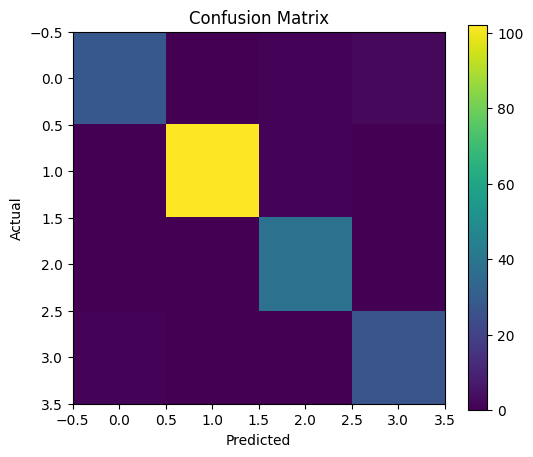

[[ 28   0   1   2]
 [  0 102   1   0]
 [  0   0  38   0]
 [  1   0   0  27]]


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(cm)

In [ ]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(10))

                             Feature  Importance
2                 daily_gaming_hours    0.245399
15           loss_of_other_interests    0.159436
14               withdrawal_symptoms    0.102885
23         monthly_game_spending_usd    0.063219
22  face_to_face_social_hours_weekly    0.054297
21            social_isolation_score    0.052288
16        continued_despite_problems    0.051876
6                        sleep_hours    0.044892
20             exercise_hours_weekly    0.037848
18                    back_neck_pain    0.021890
